# Análisis Exploratorio de Datos (EDA) Spotify

* Objetivo

El presente notebook tiene como objetivo realizar un Análisis Exploratorio de Datos (EDA, *Exploratory Data Analysis*) sobre el conjunto de datos correspondiente a pistas musicales de Spotify.

El análisis busca obtener una visión general de la estructura del dataset, evaluar su calidad, identificar características relevantes de las variables y analizar sus distribuciones mediante técnicas estadísticas y visualizaciones.

Los resultados obtenidos durante esta etapa servirán como base para las posteriores tareas de ingeniería de características, preprocesamiento y construcción de modelos de aprendizaje automático.

---

Consideraciones para la ejecución en Google Colab

En caso de ejecutar este notebook utilizando Google Colab, puede ser necesario instalar previamente la dependencia `fg-data-profiling`.

La instalación debe realizarse desde la terminal de Colab:

```bash
pip install fg-data-profiling

In [11]:
""""
EN LA TERMINAL DE COLAB: pip install fg-data-profiling
solo funciona con .xlsx

import pandas as pd
import data_profiling
from data_profiling import ProfileReport
df=pd.read_csv("Spotify_Corregido.xlsx")
df = df.drop(columns=['Unnamed: 0'])

profile = ProfileReport(df, title="Reporte de Perfilado de Datos")
profile.to_file("/reports/Informe_Ejecutivo.html")

"""

'"\nEN LA TERMINAL DE COLAB: pip install fg-data-profiling\nsolo funciona con .xlsx\n\nimport pandas as pd\nimport data_profiling\nfrom data_profiling import ProfileReport\ndf=pd.read_csv("Spotify_Corregido.xlsx")\ndf = df.drop(columns=[\'Unnamed: 0\'])\n\nprofile = ProfileReport(df, title="Reporte de Perfilado de Datos")\nprofile.to_file("/reports/Informe_Ejecutivo.html")\n\n'

Nota: Esta sección corresponde únicamente a una alternativa de ejecución en Google Colab. Si el entorno de ejecución ya dispone de las dependencias requeridas, puede omitirse.

---

## Importación y configuración del entorno

Se importan las bibliotecas necesarias para la manipulación de datos, generación de visualizaciones y configuración de las rutas del proyecto.

Además, se incorpora el directorio padre a sys.path para permitir la utilización de módulos y funciones desarrollados localmente dentro del repositorio.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
"""
En caso de que Python no encuentre en la ruta los otros directorios,
ejecutar esta configuración
"""

sys.path.append(os.path.abspath(".."))


---

## Carga del dataset

El conjunto de datos utilizado corresponde al dataset de Spotify en su versión cruda, previo a la aplicación de las etapas de limpieza y transformación.

In [13]:
df=pd.read_csv("../dataset/spotify_crudo.csv")

El archivo se encuentra almacenado en el directorio `/dataset` del proyecto y constituye el punto de partida para el análisis exploratorio.

---

## Vision General del Dataset

Esta etapa tiene como finalidad obtener una primera caracterización del conjunto de datos, considerando su estructura, dimensionalidad, tipos de datos y cardinalidad de las variables.

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [15]:
df.nunique()

Unnamed: 0          114000
track_id             89741
artists              31437
album_name           46589
track_name           73608
popularity             101
duration_ms          50697
explicit                 2
danceability          1174
energy                2083
key                     12
loudness             19480
mode                     2
speechiness           1489
acousticness          5061
instrumentalness      5346
liveness              1722
valence               1790
tempo                45653
time_signature           5
track_genre            114
dtype: int64

Se obtiene la cantidad de valores únicos presentes en cada variable.

El análisis de cardinalidad resulta especialmente relevante para las variables categóricas, ya que permite identificar aquellas que poseen una gran cantidad de categorías y que, por lo tanto, podrían requerir estrategias de codificación específicas durante el preprocesamiento.

In [16]:
df['key'].unique()

array([ 1,  0,  2,  6, 11,  8,  4,  7,  3, 10,  5,  9])

Se inspeccionan explícitamente los valores únicos de la variable key, correspondiente a la tonalidad musical de las pistas.

Esta revisión permite verificar los valores presentes en la variable y detectar posibles categorías inesperadas o valores que requieran tratamiento durante la preparación de los datos.

---

## Evaluación de la calidad de los datos

La evaluación de calidad tiene como objetivo identificar problemas que puedan afectar las etapas posteriores de análisis y modelado.

Para mantener una estructura modular, las funciones utilizadas en esta sección se encuentran implementadas en el módulo `utils.c_datos`.

In [17]:
from utils.c_datos import (
    valores_nulos,
    duplicados,
    valores_unicos
)

resultado_nulos = valores_nulos(df)
resultado_duplicados = duplicados(df)
resultado_unicos = valores_unicos(df)

Valores nulos por columna:


            nulos  porcentaje_%
artists         1      0.000877
album_name      1      0.000877
track_name      1      0.000877
Filas duplicadas: 0 (0.00%)
                  valores_unicos  porcentaje_%
Unnamed: 0                114000        100.00
track_id                   89741         78.72
track_name                 73608         64.57
duration_ms                50697         44.47
album_name                 46589         40.87
tempo                      45653         40.05
artists                    31437         27.58
loudness                   19480         17.09
instrumentalness            5346          4.69
acousticness                5061          4.44
energy                      2083          1.83
valence                     1790          1.57
liveness                    1722          1.51
speechiness                 1489          1.31
danceability                1174          1.03
track_genre                  114          0.10
popularity                   101          0.

Se ejecutan tres análisis principales: 

* `valores_nulos(df)`: permite identificar la presencia de datos faltantes y determinar qué variables presentan valores ausentes.

* `duplicados(df)`: permite detectar registros repetidos dentro del conjunto de datos.

* `valores_unicos(df)`: permite analizar la cantidad y características de los valores presentes en las variables, complementando el análisis de cardinalidad realizado anteriormente.

La utilización de funciones independientes permite mantener una separación de responsabilidades y facilita la reutilización del código durante otras etapas del proyecto.

---

## Estadistica Descriptiva

La siguiente etapa tiene como finalidad caracterizar estadísticamente las variables del dataset.

Las funciones utilizadas se encuentran implementadas en el módulo `utils.est_descriptiva`:

In [18]:
from utils.est_descriptiva import (
        estadisticas_categoricas,
        estadisticas_numericas
)

# Se calculan estadísticas diferenciadas según el tipo de variable:
display(estadisticas_numericas(df))
display(estadisticas_categoricas(df))

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,rango
Unnamed: 0,114000.0,56999.500000,32909.109681,0.000,28499.75000,56999.500000,85499.2500,113999.000,-1.260167e-16,-1.200000,113999.000
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000000,50.0000,100.000,4.640252e-02,-0.927755,100.000
duration_ms,114000.0,228029.153114,107297.712645,0.000,174066.00000,212906.000000,261506.0000,5237295.000,1.119518e+01,354.952416,5237295.000
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985,-3.994966e-01,-0.184502,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000,-5.970014e-01,-0.525711,1.000
key,114000.0,5.309140,3.559987,0.000,2.00000,5.000000,8.0000,11.000,-8.500360e-03,-1.276571,11.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532,-2.006542e+00,5.896278,54.063
mode,114000.0,0.637553,0.480709,0.000,0.00000,1.000000,1.0000,1.000,-5.723005e-01,-1.672501,1.000
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965,4.647516e+00,28.824377,0.965
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.5980,0.996,7.272949e-01,-0.949931,0.996



--- artists ---
Moda: The Beatles
artists
The Beatles        279
George Jones       271
Stevie Wonder      236
Linkin Park        224
Ella Fitzgerald    222
Prateek Kuhad      217
Feid               202
Chuck Berry        190
Håkan Hellström    183
OneRepublic        181
Name: count, dtype: int64

--- album_name ---
Moda: Alternative Christmas 2022
album_name
Alternative Christmas 2022     195
Feliz Cumpleaños con Perreo    184
Metal                          143
Halloween con perreito         123
Halloween Party 2022           115
The Complete Hank Williams     111
Fiesta portatil                110
Frescura y Perreo              106
Esto me suena a Farra          105
Perreo en Halloween            103
Name: count, dtype: int64

--- track_name ---
Moda: Run Rudolph Run
track_name
Run Rudolph Run                   151
Halloween                          88
Frosty The Snowman                 81
Little Saint Nick - 1991 Remix     76
Last Last                          75
Christmas Time    

None

---

## Visualizacion Descriptiva

La visualización constituye una etapa fundamental del EDA, ya que permite identificar patrones, distribuciones, posibles valores atípicos y diferencias en la frecuencia de las categorías.

Las funciones de visualización se encuentran implementadas en el módulo `utils.vis_descriptiva`:

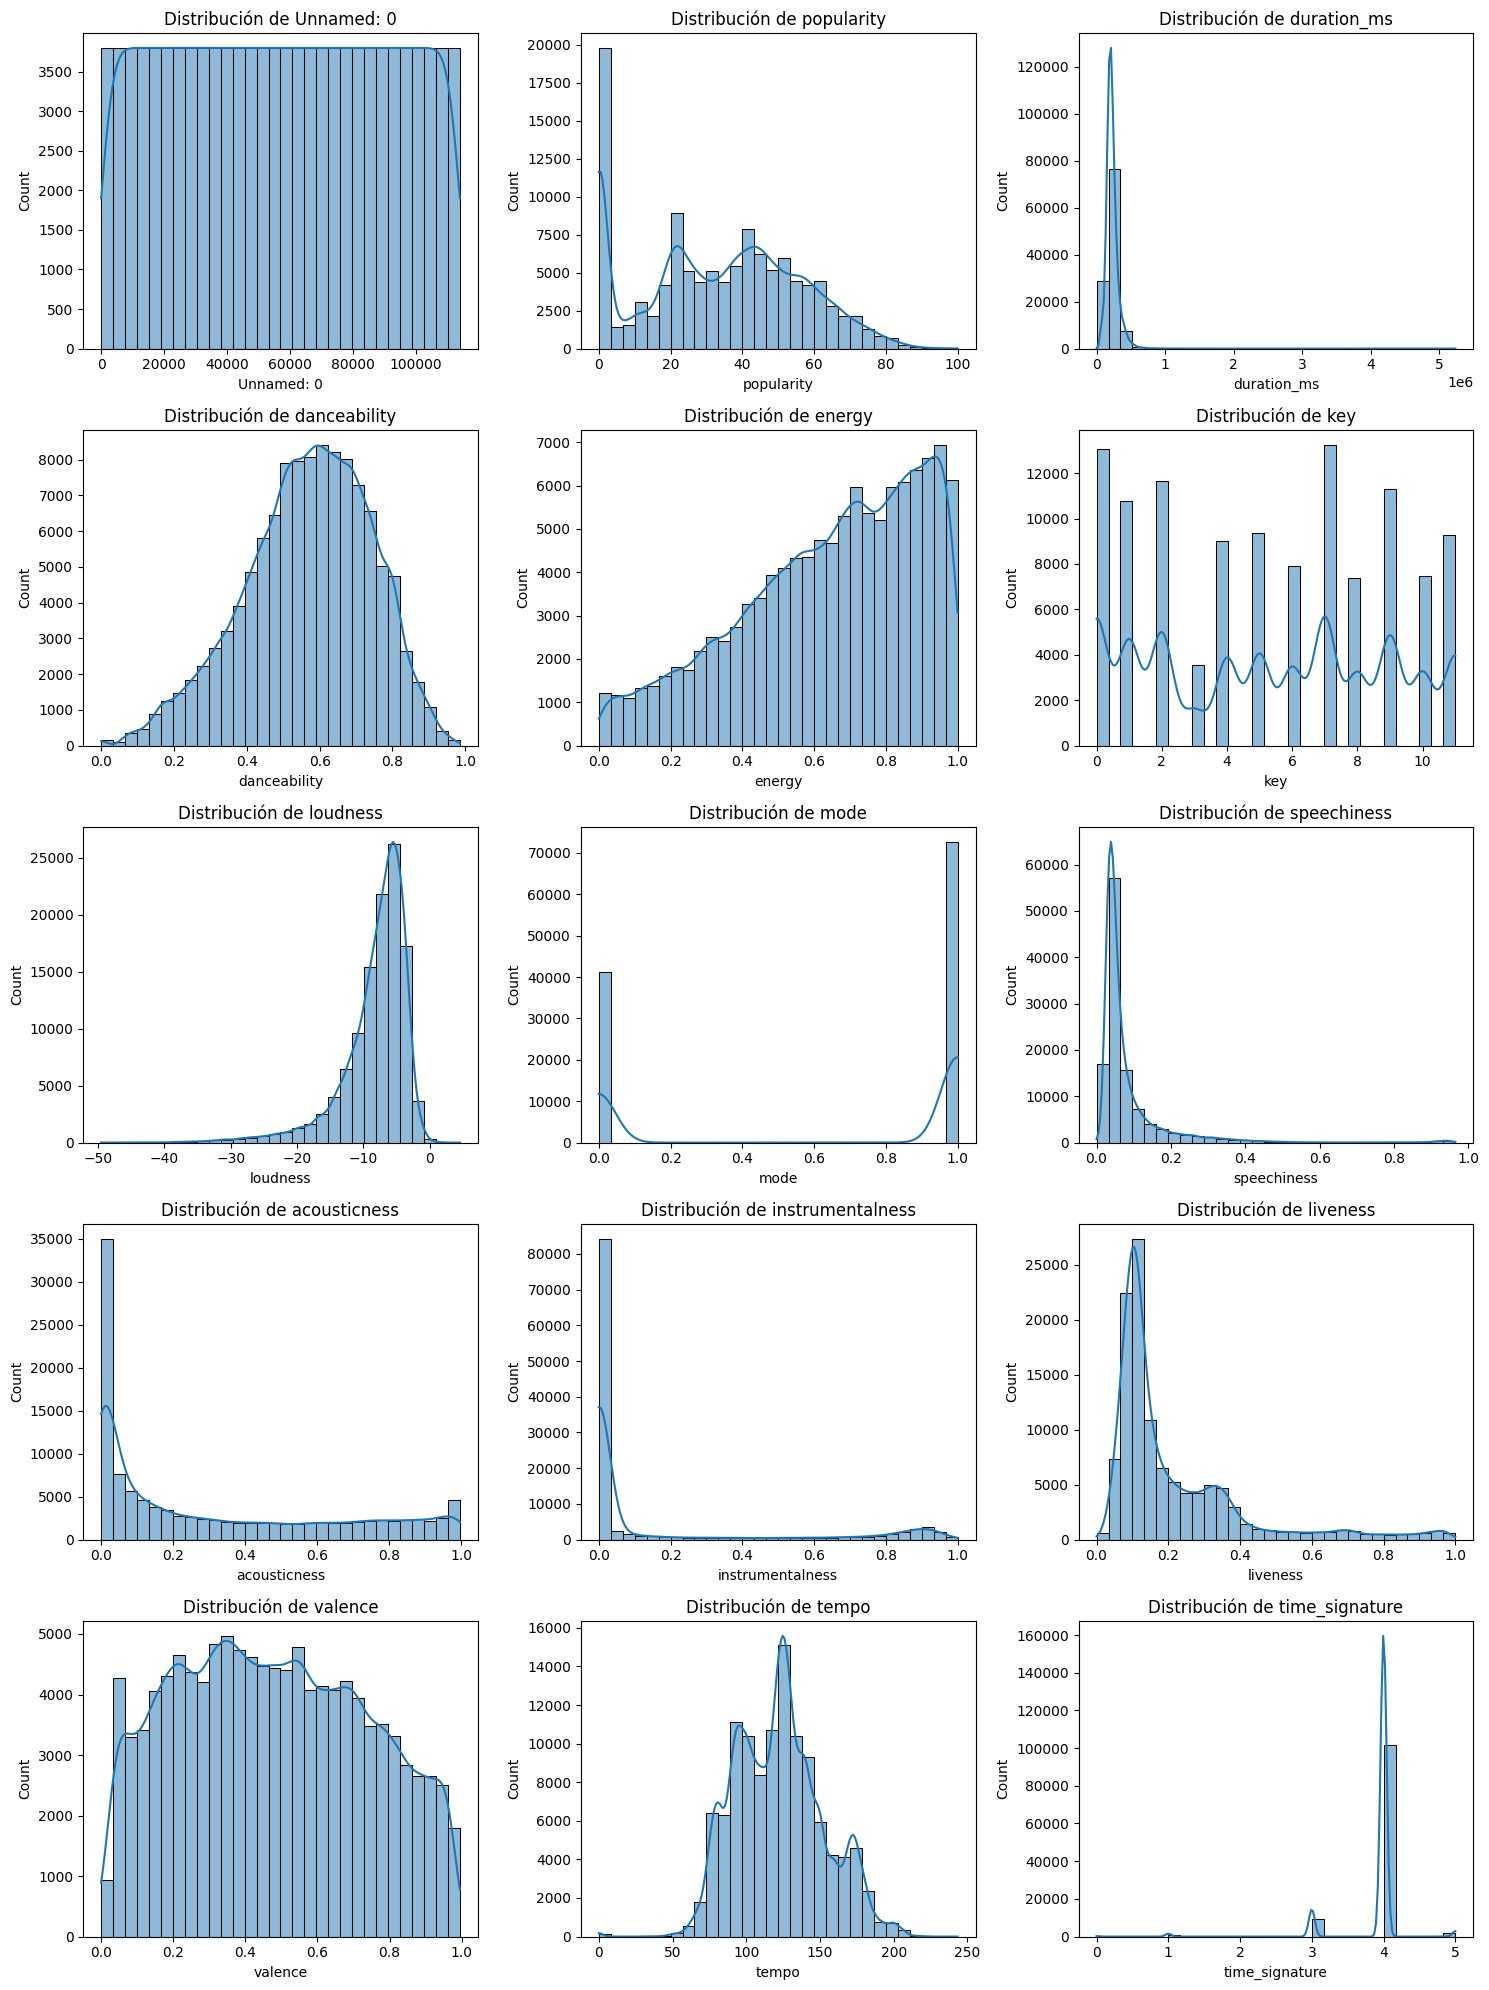

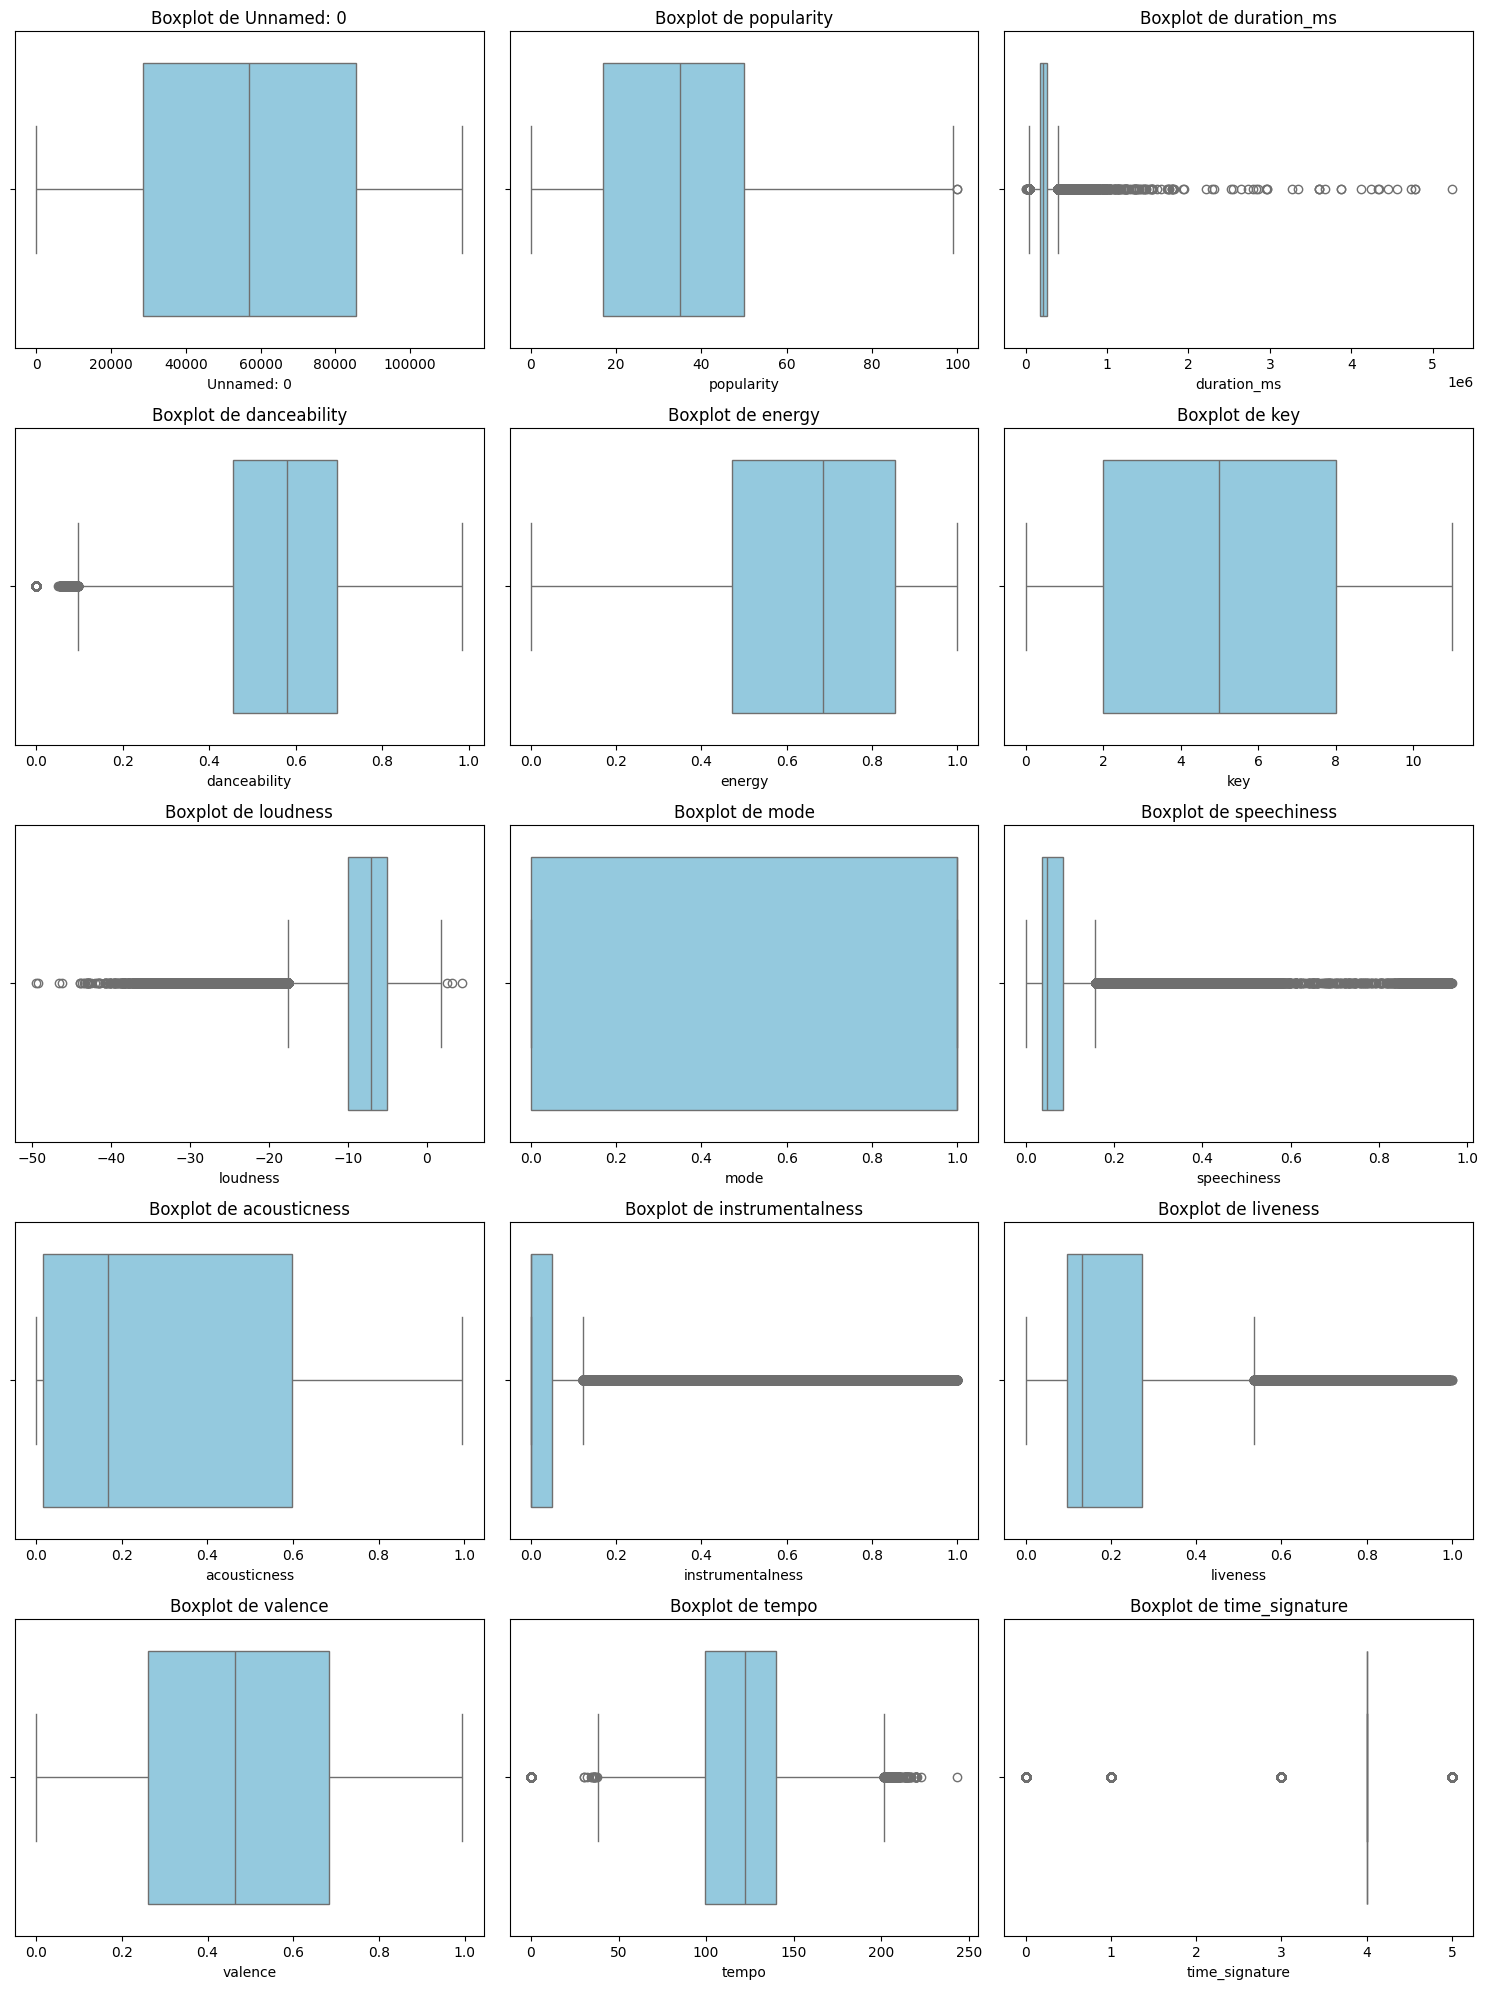

c:\Users\aarav\Documents\it\Machine_Learning\Project-MLY-1\utils\vis_descriptiva.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=top_cats, palette="viridis")


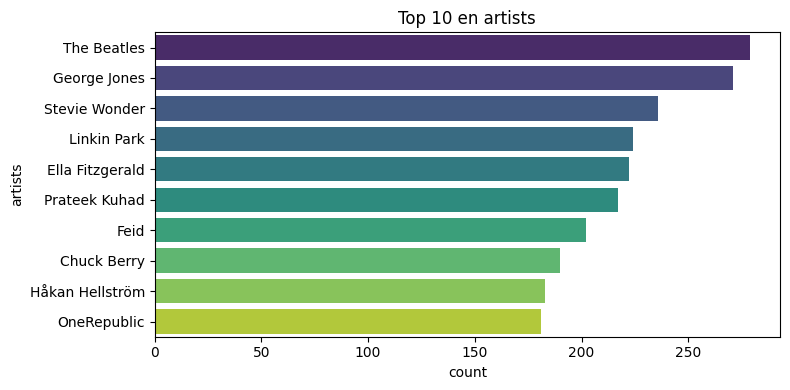

c:\Users\aarav\Documents\it\Machine_Learning\Project-MLY-1\utils\vis_descriptiva.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=top_cats, palette="viridis")


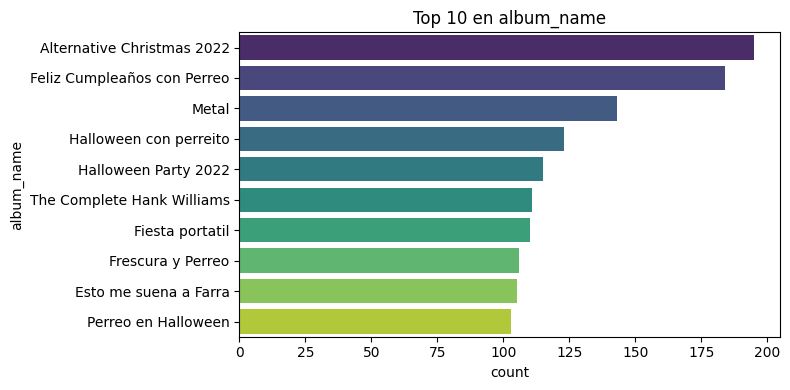

c:\Users\aarav\Documents\it\Machine_Learning\Project-MLY-1\utils\vis_descriptiva.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=top_cats, palette="viridis")


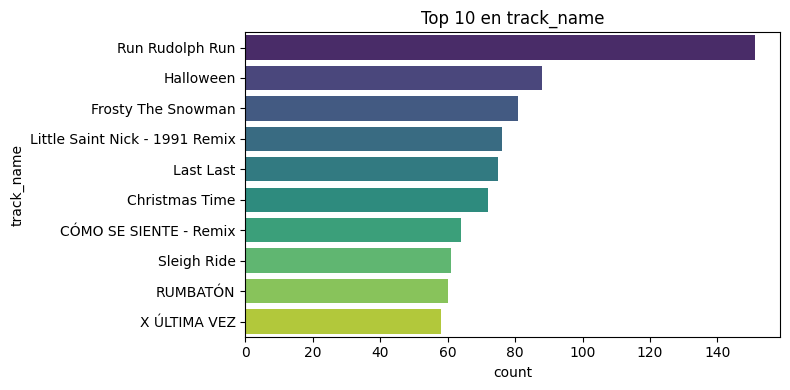

c:\Users\aarav\Documents\it\Machine_Learning\Project-MLY-1\utils\vis_descriptiva.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=top_cats, palette="viridis")


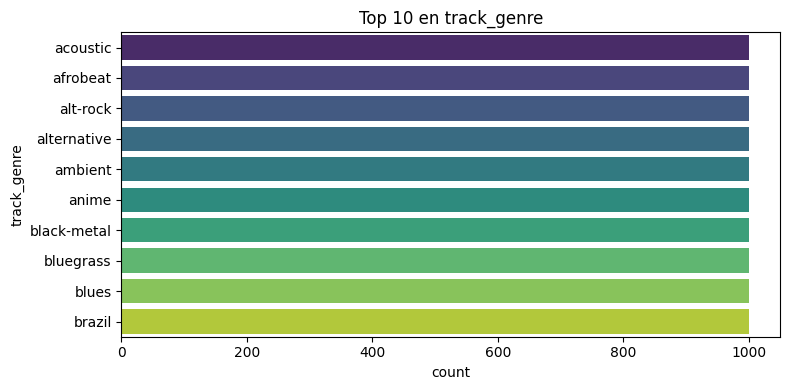

In [19]:
from utils.vis_descriptiva import (
    graficar_distribuciones_numericas,
    graficar_categoricas,
    graficar_boxplots
)

graficar_distribuciones_numericas(df)
graficar_boxplots(df)
graficar_categoricas(df)

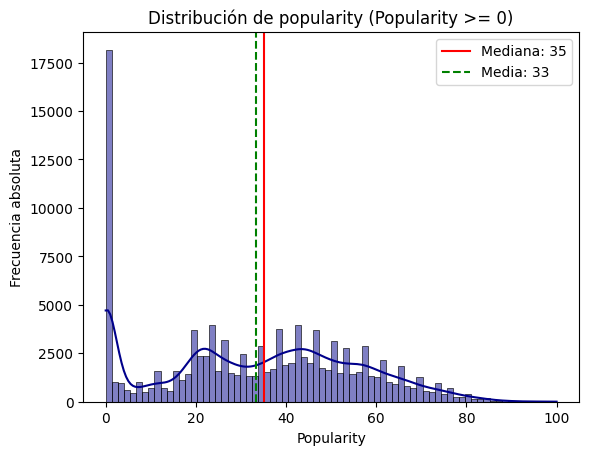

In [21]:
sns.histplot(
    data=df,
    x='popularity',
    kde=True,
    color='darkblue'
)

plt.axvline(
    df['popularity'].median(),
    label=f"Mediana: {df['popularity'].median():.0f}",
    color='red'
)

plt.axvline(
    df['popularity'].mean(),
    label=f"Media: {df['popularity'].mean():.0f}",
    color='green',
    linestyle='--'
)

plt.title('Distribución de popularity (Popularity >= 0)')
plt.xlabel('Popularity')
plt.ylabel('Frecuencia absoluta')

plt.legend()
plt.show()

In [22]:
cantidad_ceros = (df['popularity'] == 0).sum()
porcentaje_ceros = (cantidad_ceros / len(df)) * 100

print(f"Cantidad de valores 0: {cantidad_ceros}")
print(f"Porcentaje de valores 0: {porcentaje_ceros:.2f}%")

Cantidad de valores 0: 16020
Porcentaje de valores 0: 14.05%
